# PASSO 3 - Treinamento de Modelo (XGBoost)
Nesse passo, vamos treinar modelos XGBoost para cada traço de personalidade MBTI.

## 0. Setup
Importar os pacotes necessários para rodar o resto do código.

In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score
from pipeline.smote_oversampling import SMOTEOversampler
from pipeline.machine_learning_algorithms.xgboost import XGBoostClassifier


N_HUMAN_POSTS = 6940
DATA_DIR = Path("data")
TRAIN_DIR = DATA_DIR / "train_datasets"
TEST_DIR = DATA_DIR / "test_datasets"
MODELS_DIR = Path("models/xgboost")
XGB_PARAMS = dict(
    n_estimators=800, 
    learning_rate=0.03, 
    max_depth=12, 
    subsample=0.8, 
    colsample_bytree=0.8, 
    random_state=42,
    n_jobs=-1
)

def divide_mbti(y_series):
    """Converte a string MBTI (ex: 'INFJ') em 4 colunas binárias (I/E, N/S, T/F, J/P)."""
    y_df = pd.DataFrame()
    y_df['I_E'] = (y_series.str[0] == 'I').astype(int)
    y_df['N_S'] = (y_series.str[1] == 'N').astype(int)
    y_df['T_F'] = (y_series.str[2] == 'T').astype(int)
    y_df['J_P'] = (y_series.str[3] == 'J').astype(int)
    return y_df

def load_train_test(embedding):
    """Carrega x_train/x_test (para um embedding) e y_train/y_test (comuns a todos)."""
    x_train = pd.read_pickle(TRAIN_DIR / f"x_train_{embedding}.pkl")
    x_test = pd.read_pickle(TEST_DIR / f"x_test_{embedding}.pkl")
    y_train = pd.Series(pd.read_pickle(TRAIN_DIR / "y_train.pkl"))
    y_test = pd.Series(pd.read_pickle(TEST_DIR / "y_test.pkl"))
    return x_train, x_test, y_train, y_test

def load_train_test_gpt2(embedding):
    """Carrega x_train/x_test (para um embedding) e y_train/y_test (comuns a todos)."""
    x_train = pd.read_pickle(TRAIN_DIR / f"x_train_{embedding}_gpt2.pkl")
    x_test = pd.read_pickle(TEST_DIR / f"x_test_{embedding}.pkl")
    y_train = pd.Series(pd.read_pickle(TRAIN_DIR / "y_train.pkl"))
    y_test = pd.Series(pd.read_pickle(TEST_DIR / "y_test.pkl"))
    return x_train, x_test, y_train, y_test

def save_models(clf, label):
    """Salva os 4 submodelos (um por traço MBTI) com sufixo `label`."""
    for key, model in clf.models.items():
        path = MODELS_DIR / f"{key}_{label}.json"
        model.save_model(str(path))
        print(f"Salvo: {path}")

def run_experiment(embedding, label, *, use_smote=True, human_only=False):
    """Carrega dados, (opcionalmente) aplica SMOTE, treina, avalia e salva os modelos.

    - `human_only=True`: restringe o treino aos posts humanos originais (sem augmentação SLM).
    - `use_smote=False`: não aplica oversampling (baseline sem SMOTE).
    Retorna o classificador treinado (predições ficam disponíveis via clf.predict)."""
    x_train, x_test, y_train, y_test = load_train_test(embedding)

    if human_only:
        assert len(x_train) >= N_HUMAN_POSTS, (
            f"x_train ({len(x_train)}) menor que N_HUMAN_POSTS ({N_HUMAN_POSTS}); "
            "verifique a ordem de concatenação no passo 2."
        )
        x_train = x_train[:N_HUMAN_POSTS]
        y_train = y_train[:N_HUMAN_POSTS]

    if use_smote:
        x_train, y_train = SMOTEOversampler(random_state=42).fit_resample(x_train, y_train)

    y_train_4cols = divide_mbti(y_train)
    y_test_4cols = divide_mbti(y_test.reset_index(drop=True))

    clf = XGBoostClassifier(**XGB_PARAMS)
    clf.fit(x_train, y_train_4cols)
    clf.evaluate(x_test, y_test_4cols)
    save_models(clf, label)
    return clf

def run_experiment_gpt2(embedding, label, *, use_smote=True, human_only=False):
    """Carrega dados, (opcionalmente) aplica SMOTE, treina, avalia e salva os modelos.

    - `human_only=True`: restringe o treino aos posts humanos originais (sem augmentação SLM).
    - `use_smote=False`: não aplica oversampling (baseline sem SMOTE).
    Retorna o classificador treinado (predições ficam disponíveis via clf.predict)."""
    x_train, x_test, y_train, y_test = load_train_test_gpt2(embedding)

    if human_only:
        assert len(x_train) >= N_HUMAN_POSTS, (
            f"x_train ({len(x_train)}) menor que N_HUMAN_POSTS ({N_HUMAN_POSTS}); "
            "verifique a ordem de concatenação no passo 2."
        )
        x_train = x_train[:N_HUMAN_POSTS]
        y_train = y_train[:N_HUMAN_POSTS]

    if use_smote:
        x_train, y_train = SMOTEOversampler(random_state=42).fit_resample(x_train, y_train)

    y_train_4cols = divide_mbti(y_train)
    y_test_4cols = divide_mbti(y_test.reset_index(drop=True))

    clf = XGBoostClassifier(**XGB_PARAMS)
    clf.fit(x_train, y_train_4cols)
    clf.evaluate(x_test, y_test_4cols)
    save_models(clf, label)
    return clf

## 1. Baseline
Treina apenas com os posts humanos originais, sem aplicação de técnicas de balanceamento de classes. Serve como parâmetro de controle para avaliar o ganho das otimizações posteriores.

#### TF-IDF

In [ ]:
tfidf_baseline = run_experiment('tfidf', 'tfidf_baseline', use_smote=False, human_only=True)

#### Word2Vec

In [ ]:
w2v_baseline = run_experiment('w2v', 'w2v_baseline', use_smote=False, human_only=True)

## 2. Baseline + SMOTE
Treina com um over-sampling SMOTE dos dados originais. Gerando amostras sintéticas baseadas nas classes minoritárias, visando reduzir o viés do modelo.

#### TF-IDF

In [ ]:
tfidf_smote = run_experiment('tfidf', 'tfidf_smote', use_smote=True, human_only=True)

#### Word2Vec

In [ ]:
w2v_smote = run_experiment('w2v', 'w2v_smote', use_smote=True, human_only=True)

## 3. Baseline + SMOTE + SLM (QWEN)
Treina com um over-sampling e um augmentation de SLM (qwen) dos dados originais. O objetivo é testar se a variabilidade introduzida pela IA melhora a capacidade de generalização do modelo.

#### TF-IDF

In [5]:
tfidf_aug = run_experiment_gpt2('tfidf', 'tfidf_aug', use_smote=True, human_only=False)

Original dataset shape: X=(9322, 10000), y=(9322,)


/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Resampled dataset shape: X=(23456, 10000), y=(23456,)
Starting training process...
 -> Training model for I_E...
 -> Training model for N_S...
 -> Training model for T_F...
 -> Training model for J_P...
All 4 models trained successfully! ✅

Evaluation for dimension: I_E
Accuracy: 0.7971

              precision    recall  f1-score   support

           0       0.65      0.27      0.38       401
           1       0.81      0.96      0.88      1334

    accuracy                           0.80      1735
   macro avg       0.73      0.61      0.63      1735
weighted avg       0.77      0.80      0.76      1735


Evaluation for dimension: N_S
Accuracy: 0.8744

              precision    recall  f1-score   support

           0       0.74      0.14      0.24       240
           1       0.88      0.99      0.93      1495

    accuracy                           0.87      1735
   macro avg       0.81      0.57      0.58      1735
weighted avg       0.86      0.87      0.84      1735


Evaluat

#### Word2Vec

In [6]:
w2v_aug = run_experiment_gpt2('w2v', 'w2v_aug', use_smote=True, human_only=False)

Original dataset shape: X=(9322, 500), y=(9322,)
Resampled dataset shape: X=(23456, 500), y=(23456,)
Starting training process...
 -> Training model for I_E...


/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


 -> Training model for N_S...
 -> Training model for T_F...
 -> Training model for J_P...
All 4 models trained successfully! ✅

Evaluation for dimension: I_E
Accuracy: 0.7579

              precision    recall  f1-score   support

           0       0.45      0.20      0.28       401
           1       0.79      0.93      0.85      1334

    accuracy                           0.76      1735
   macro avg       0.62      0.56      0.57      1735
weighted avg       0.71      0.76      0.72      1735


Evaluation for dimension: N_S
Accuracy: 0.8530

              precision    recall  f1-score   support

           0       0.41      0.14      0.21       240
           1       0.87      0.97      0.92      1495

    accuracy                           0.85      1735
   macro avg       0.64      0.55      0.56      1735
weighted avg       0.81      0.85      0.82      1735


Evaluation for dimension: T_F
Accuracy: 0.7666

              precision    recall  f1-score   support

           0     

## 4. Análise Comparativa
Avaliação da performance preditiva dos modelos, comparando os resultados das predições de cada experimento.

In [13]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score

MODELS_DIR = "models/xgboost"
TEST_DIR = "data/test_datasets"

# ----------------------------
# Testes padrão
# ----------------------------
with open(f"{TEST_DIR}/X_test_tfidf.pkl", "rb") as f:
    X_test_tfidf = pickle.load(f)

with open(f"{TEST_DIR}/X_test_w2v.pkl", "rb") as f:
    X_test_w2v = pickle.load(f)

with open(f"{TEST_DIR}/y_test.pkl", "rb") as f:
    y_test_raw = pd.Series(pickle.load(f))

y_test_4cols = divide_mbti(y_test_raw)

# ----------------------------
# Testes GPT-2
# ----------------------------
with open(f"{TEST_DIR}/X_test_tfidf_gpt2.pkl", "rb") as f:
    X_test_tfidf_gpt2 = pickle.load(f)

with open(f"{TEST_DIR}/X_test_w2v_gpt2.pkl", "rb") as f:
    X_test_w2v_gpt2 = pickle.load(f)

with open(f"{TEST_DIR}/y_test_gpt2.pkl", "rb") as f:
    y_test_raw_gpt2 = pd.Series(pickle.load(f))

y_test_4cols_gpt2 = divide_mbti(y_test_raw_gpt2)

In [14]:
def load_classifier(label):
    clf = XGBoostClassifier()
    clf.load_models(label, MODELS_DIR)
    return clf

# ----------------------------
# Base (sem SMOTE)
# ----------------------------
clf_tfidf_base = load_classifier("tfidf_qwen_original_posts")
clf_w2v_base   = load_classifier("w2v_qwen_original_posts")

# ----------------------------
# Apenas SMOTE
# ----------------------------
clf_tfidf_smote = load_classifier("posts_tfidf_oversampled")
clf_w2v_smote   = load_classifier("posts_w2v_oversampled")

# ----------------------------
# Qwen + SMOTE
# ----------------------------
clf_tfidf_qwen = load_classifier("tfidf_qwen")
clf_w2v_qwen   = load_classifier("w2v_qwen")

# ----------------------------
# GPT-2 + SMOTE
# ----------------------------
clf_tfidf_gpt = load_classifier("tfidf_aug")
clf_w2v_gpt   = load_classifier("w2v_aug")

Loading models/xgboost/I_E_tfidf_qwen_original_posts.json
Loading models/xgboost/N_S_tfidf_qwen_original_posts.json
Loading models/xgboost/T_F_tfidf_qwen_original_posts.json
Loading models/xgboost/J_P_tfidf_qwen_original_posts.json
All models loaded successfully! ✅
Loading models/xgboost/I_E_w2v_qwen_original_posts.json
Loading models/xgboost/N_S_w2v_qwen_original_posts.json
Loading models/xgboost/T_F_w2v_qwen_original_posts.json
Loading models/xgboost/J_P_w2v_qwen_original_posts.json
All models loaded successfully! ✅
Loading models/xgboost/I_E_posts_tfidf_oversampled.json
Loading models/xgboost/N_S_posts_tfidf_oversampled.json
Loading models/xgboost/T_F_posts_tfidf_oversampled.json
Loading models/xgboost/J_P_posts_tfidf_oversampled.json
All models loaded successfully! ✅
Loading models/xgboost/I_E_posts_w2v_oversampled.json
Loading models/xgboost/N_S_posts_w2v_oversampled.json
Loading models/xgboost/T_F_posts_w2v_oversampled.json
Loading models/xgboost/J_P_posts_w2v_oversampled.json
Al

In [15]:
predictions = {
    "TF-IDF": {
        "1. Base (No SMOTE)": (
            clf_tfidf_base.predict(X_test_tfidf),
            y_test_4cols
        ),
        "2. SMOTE Only": (
            clf_tfidf_smote.predict(X_test_tfidf),
            y_test_4cols
        ),
        "3. Qwen + SMOTE": (
            clf_tfidf_qwen.predict(X_test_tfidf),
            y_test_4cols
        ),
        "4. GPT-2 + SMOTE": (
            clf_tfidf_gpt.predict(X_test_tfidf_gpt2),
            y_test_4cols_gpt2
        ),
    },

    "Word2Vec": {
        "1. Base (No SMOTE)": (
            clf_w2v_base.predict(X_test_w2v),
            y_test_4cols
        ),
        "2. SMOTE Only": (
            clf_w2v_smote.predict(X_test_w2v),
            y_test_4cols
        ),
        "3. Qwen + SMOTE": (
            clf_w2v_qwen.predict(X_test_w2v),
            y_test_4cols
        ),
        "4. GPT-2 + SMOTE": (
            clf_w2v_gpt.predict(X_test_w2v_gpt2),
            y_test_4cols_gpt2
        ),
    }
}

colunas = ['I_E', 'N_S', 'T_F', 'J_P']
nomes_eixos = ['I/E\n(Introvert/Extravert)', 'N/S\n(Intuition/Sensing)', 'T/F\n(Thinking/Feeling)', 'J/P\n(Judging/Perceiving)']

dados = []

for emb, modelos in predictions.items():
    for metodo, (pred, y_true) in modelos.items():
        for eixo, nome in zip(colunas, nomes_eixos):
            dados.append({
                "Embedding": emb,
                "Axis": nome,
                "Method": metodo,
                "F1 (%)": 100 * f1_score(
                    y_true[eixo],
                    pred[eixo],
                    average="weighted"
                )
            })

df_plot = pd.DataFrame(dados)

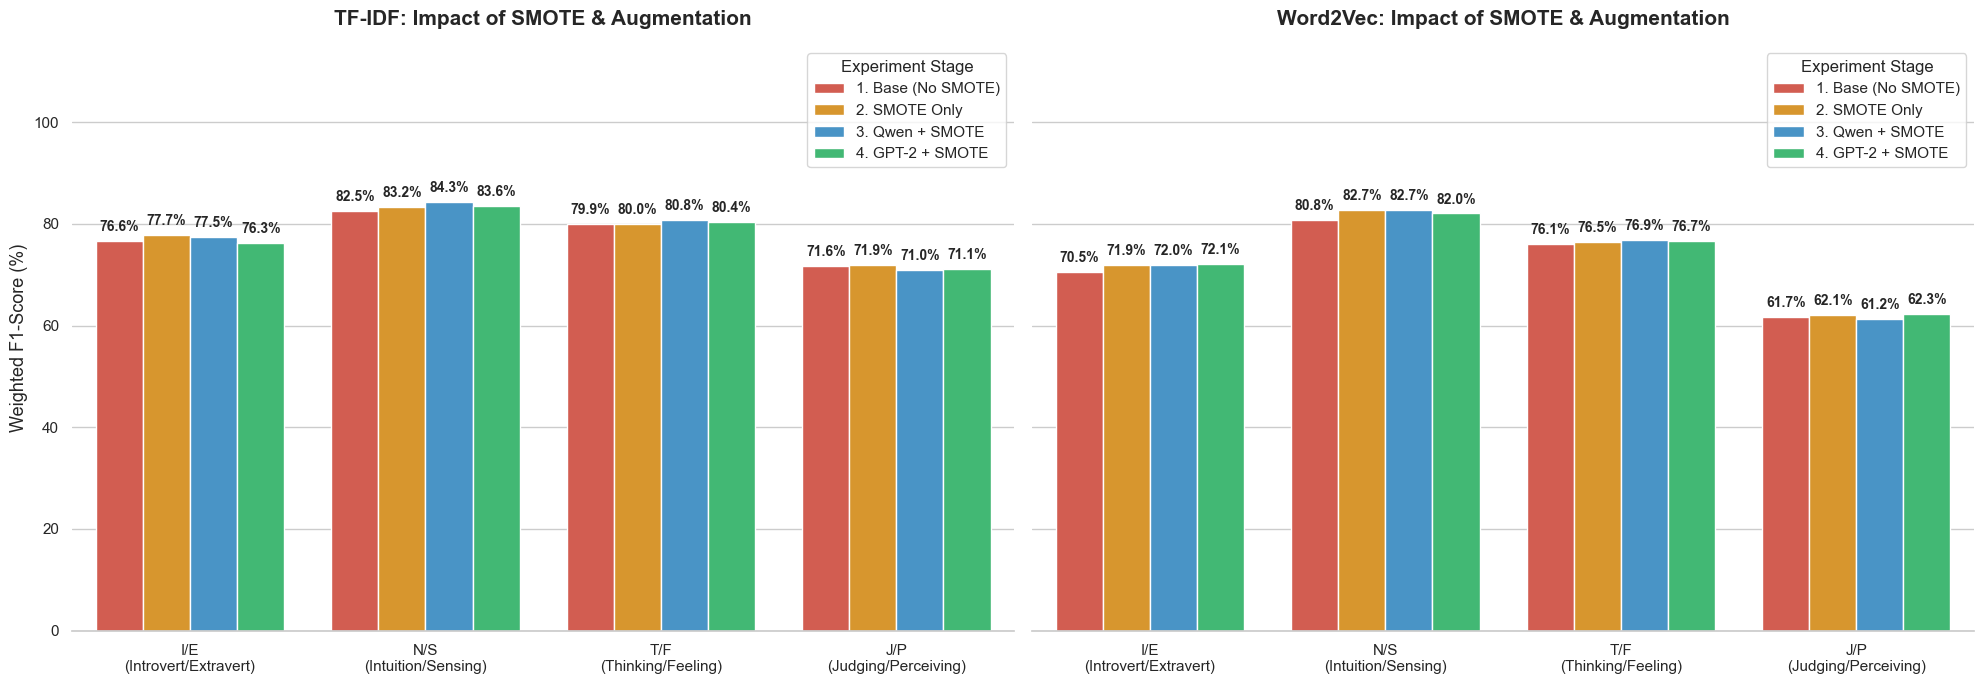

In [16]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(
    1,
    2,
    figsize=(20, 7),
    sharey=True
)

palette = [
    "#e74c3c",
    "#f39c12",
    "#3498db",
    "#2ecc71"
]

for ax, emb in zip(axes, ["TF-IDF", "Word2Vec"]):
    sns.barplot(
        data=df_plot[df_plot["Embedding"] == emb],
        x="Axis",
        y="F1 (%)",
        hue="Method",
        palette=palette,
        ax=ax
    )

    ax.set_title(
        f"{emb}: Impact of SMOTE & Augmentation",
        fontsize=15,
        fontweight="bold",
        pad=15
    )

    ax.set_ylim(0, 115)
    ax.set_xlabel("")

    if emb == "TF-IDF":
        ax.set_ylabel("Weighted F1-Score (%)", fontsize=13)
    else:
        ax.set_ylabel("")

    for p in ax.patches:
        h = p.get_height()
        if h > 0:
            ax.annotate(
                f"{h:.1f}%",
                (p.get_x() + p.get_width() / 2., h),
                ha="center",
                va="bottom",
                fontsize=10,
                fontweight="bold",
                xytext=(0, 5),
                textcoords="offset points"
            )

    ax.legend(title="Experiment Stage", fontsize="11", loc="upper right")

sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()